<a href="https://colab.research.google.com/github/wirayudhabn/uas-daa-knapsack/blob/main/knapsack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mulai Stress-Testing Algoritma...
✓ Selesai N=10   | W=50    | DP: 0.0003s | Greedy: 0.0019s
✓ Selesai N=50   | W=250   | DP: 0.0072s | Greedy: 0.0048s
✓ Selesai N=100  | W=500   | DP: 0.0252s | Greedy: 0.0076s
✓ Selesai N=200  | W=1000  | DP: 0.0681s | Greedy: 0.0087s
✓ Selesai N=500  | W=2500  | DP: 0.5069s | Greedy: 0.0208s
✓ Selesai N=1000 | W=5000  | DP: 2.1041s | Greedy: 0.0428s


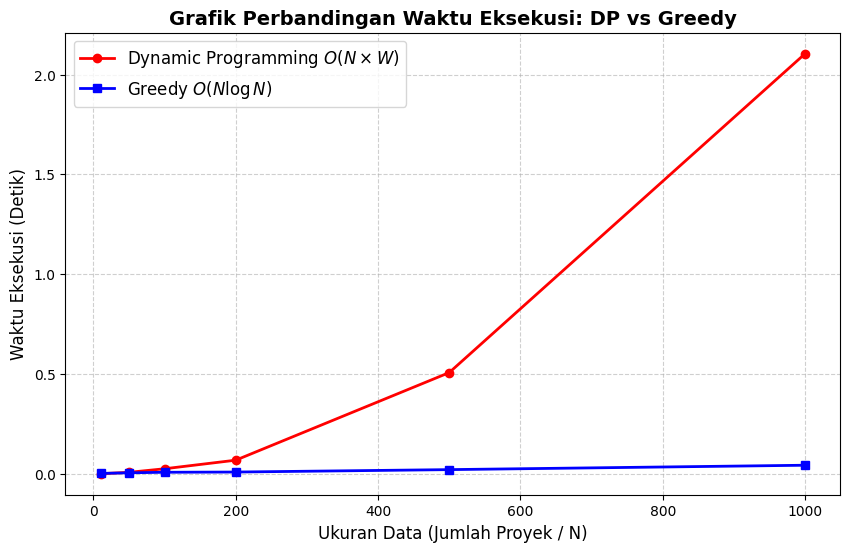

In [3]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# ==========================================
# 1. CLASS: DATA GENERATOR
# ==========================================
class DatasetGenerator:
    """Class khusus untuk memproduksi data fiksi / sintetis."""

    @staticmethod
    def generate_synthetic_data(N, random_seed=None):
        if random_seed:
            np.random.seed(random_seed)

        durasi = np.random.randint(1, 24, size=N)
        profit = np.random.randint(100000, 5000000, size=N)

        df = pd.DataFrame({
            'ID_Proyek': [f'P{i}' for i in range(N)],
            'Durasi_Jam': durasi,
            'Profit_Rp': profit
        })
        df['Rasio_Profit_Per_Jam'] = df['Profit_Rp'] / df['Durasi_Jam']
        return df

# ==========================================
# 2. CLASS: ALGORITHM SOLVER
# ==========================================
class KnapsackSolver:
    """Class berisi koleksi algoritma penyelesaian."""

    @staticmethod
    def greedy_approach(df, W):
        start_time = time.perf_counter()

        df_sorted = df.sort_values(by='Rasio_Profit_Per_Jam', ascending=False)

        total_profit = 0
        total_jam = 0

        for _, row in df_sorted.iterrows():
            if total_jam + row['Durasi_Jam'] <= W:
                total_jam += row['Durasi_Jam']
                total_profit += row['Profit_Rp']

        execution_time = time.perf_counter() - start_time
        return total_profit, execution_time

    @staticmethod
    def dp_approach(df, W):
        start_time = time.perf_counter()

        n = len(df)
        jam = df['Durasi_Jam'].tolist()
        profit = df['Profit_Rp'].tolist()

        dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]

        for i in range(1, n + 1):
            for w in range(1, W + 1):
                if jam[i-1] <= w:
                    dp[i][w] = max(profit[i-1] + dp[i-1][w-jam[i-1]], dp[i-1][w])
                else:
                    dp[i][w] = dp[i-1][w]

        total_profit = dp[n][W]
        execution_time = time.perf_counter() - start_time
        return total_profit, execution_time

# ==========================================
# 3. CLASS: EXPERIMENT RUNNER
# ==========================================
class ExperimentRunner:
    """Class untuk mengeksekusi pengujian dan visualisasi."""

    def __init__(self, data_sizes, W_factor=5):
        self.data_sizes = data_sizes
        self.W_factor = W_factor
        self.results = {
            'N': [], 'W': [],
            'Greedy_Time': [], 'DP_Time': [],
            'Greedy_Profit': [], 'DP_Profit': []
        }

    def run(self):
        print("Mulai Stress-Testing Algoritma...\n" + "="*40)

        for N in self.data_sizes:
            W = N * self.W_factor
            df_test = DatasetGenerator.generate_synthetic_data(N)

            # Eksekusi Greedy
            g_profit, g_time = KnapsackSolver.greedy_approach(df_test, W)

            # Eksekusi DP
            dp_profit, dp_time = KnapsackSolver.dp_approach(df_test, W)

            # Simpan Hasil
            self.results['N'].append(N)
            self.results['W'].append(W)
            self.results['Greedy_Time'].append(g_time)
            self.results['DP_Time'].append(dp_time)
            self.results['Greedy_Profit'].append(g_profit)
            self.results['DP_Profit'].append(dp_profit)

            print(f"✓ Selesai N={N:<4} | W={W:<5} | DP: {dp_time:.4f}s | Greedy: {g_time:.4f}s")

    def plot_results(self):
        #
        plt.figure(figsize=(10, 6))
        plt.plot(self.results['N'], self.results['DP_Time'], marker='o', color='red', label='Dynamic Programming $O(N \\times W)$', linewidth=2)
        plt.plot(self.results['N'], self.results['Greedy_Time'], marker='s', color='blue', label='Greedy $O(N \\log N)$', linewidth=2)

        plt.title('Grafik Perbandingan Waktu Eksekusi: DP vs Greedy', fontsize=14, fontweight='bold')
        plt.xlabel('Ukuran Data (Jumlah Proyek / N)', fontsize=12)
        plt.ylabel('Waktu Eksekusi (Detik)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(fontsize=12)
        plt.show()

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Tentukan skala data uji (N)
    skala_pengujian = [10, 50, 100, 200, 500, 1000]

    # Inisialisasi dan jalankan eksperimen
    eksperimen = ExperimentRunner(data_sizes=skala_pengujian, W_factor=5)
    eksperimen.run()

    # Tampilkan Grafik
    eksperimen.plot_results()